In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})


In [167]:
# load data & setup colours

# load both datasets
df_natural = pd.read_csv('evaluation_results\\natural_checkpoints_evaluation.csv')
df_noise = pd.read_csv('evaluation_results\\noise_checkpoints_evaluation.csv')

# add labels based on what type of patch
df_natural['patch_type'] = 'Natural'
df_noise['patch_type'] = 'Noise'

df_combined = pd.concat([df_natural, df_noise], ignore_index=True)

best_epoch_natural = df_natural['epoch'].max()
best_epoch_noise = df_noise['epoch'].max()

df_final_natural = df_natural[df_natural['epoch'] == best_epoch_natural].copy()
df_final_noise = df_noise[df_noise['epoch'] == best_epoch_noise].copy()
df_final_combined = pd.concat([df_final_natural, df_final_noise], ignore_index=True)

df_final_combined['relative_conf_drop_pct'] = (df_final_combined['conf_drop'] / df_final_combined['baseline_conf']) * 100

# color palettes
global_state_palette = {
    'Baseline': '#2ca02c',
    'Natural': '#1f77b4',
    'Noise': '#d62728'
}

global_vehicle_palette = {
    'vehicle.audi.tt': '#9467bd',
    'vehicle.nissan.patrol': '#ff7f0e',
    'vehicle.tesla.model3': '#17becf',
    'vehicle.toyota.prius': '#e377c2',
    'vehicle.seat.leon': "#54d032"
}

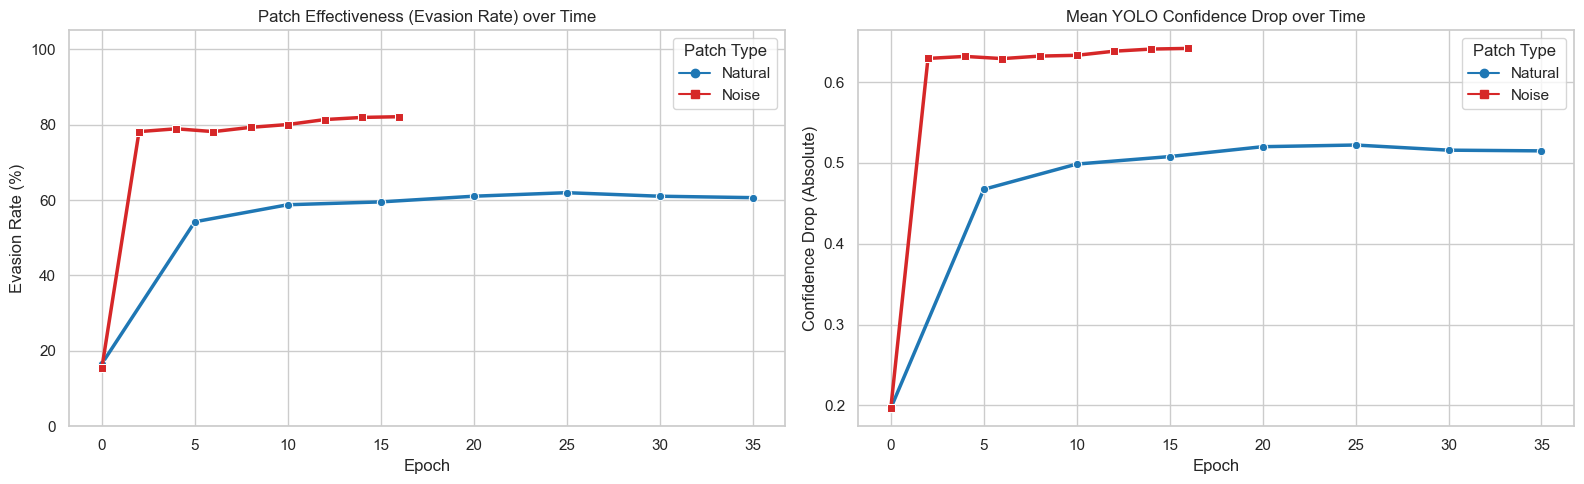

In [168]:
# 1.training curves: evasion rate and confidence drop over epochs


epoch_stats = df_combined.groupby(['patch_type', 'epoch']).agg(
    total_baseline_detected=('baseline_detected', 'sum'),
    total_evasions=('evasion_success', 'sum'),
    mean_conf_drop=('conf_drop', 'mean')
).reset_index()

epoch_stats['evasion_rate'] = (epoch_stats['total_evasions'] / epoch_stats['total_baseline_detected']) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# evasion Rate
sns.lineplot(data=epoch_stats, x='epoch', y='evasion_rate', hue='patch_type', 
             style='patch_type', markers=['o', 's'], dashes=False, ax=axes[0], linewidth=2.5,
             palette=global_state_palette) # <--- LOCKED
axes[0].set_title('Patch Effectiveness (Evasion Rate) over Time')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Evasion Rate (%)')
axes[0].set_ylim(0, 105)
axes[0].legend(title='Patch Type')

# confidence Drop
sns.lineplot(data=epoch_stats, x='epoch', y='mean_conf_drop', hue='patch_type', 
             style='patch_type', markers=['o', 's'], dashes=False, ax=axes[1], linewidth=2.5,
             palette=global_state_palette) # <--- LOCKED
axes[1].set_title('Mean YOLO Confidence Drop over Time')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Confidence Drop (Absolute)')
axes[1].legend(title='Patch Type')

plt.tight_layout()
plt.show()

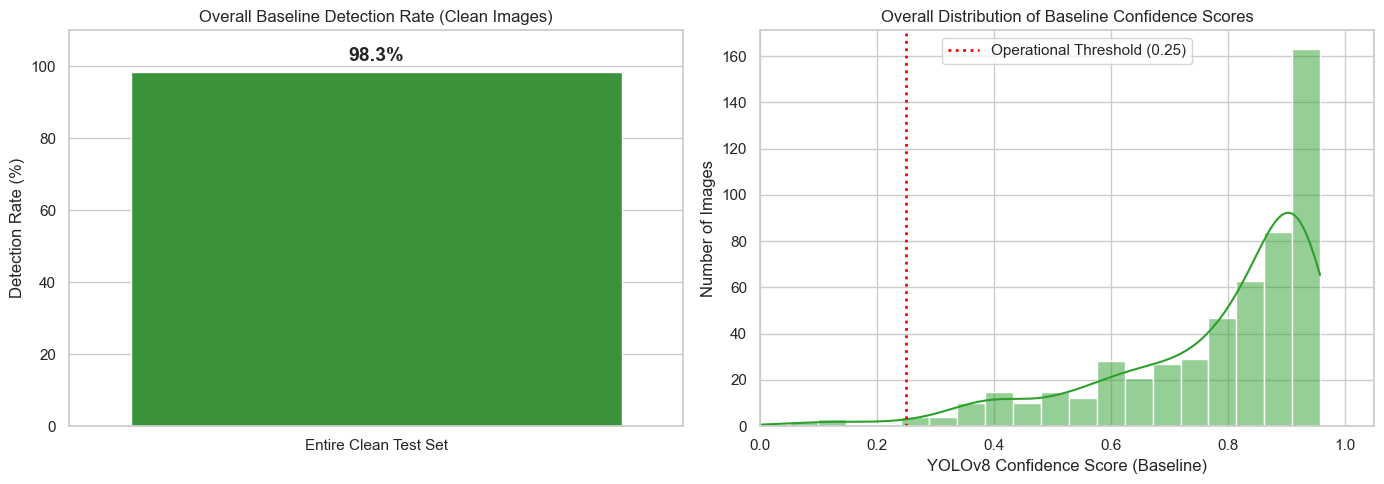

In [169]:
# 2. Baseline Detection Rate & Confidence Distribution

df_baseline = df_final_combined.drop_duplicates(subset=['filename']).copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

total_images = len(df_baseline)
total_detected = df_baseline['baseline_detected'].sum()
overall_rate = (total_detected / total_images) * 100
overall_mean_conf = df_baseline['baseline_conf'].mean()


# Baseline Detection Rate
sns.barplot(x=['Entire Clean Test Set'], y=[overall_rate], color=global_state_palette['Baseline'], ax=axes[0])
axes[0].set_title('Overall Baseline Detection Rate (Clean Images)')
axes[0].set_ylabel('Detection Rate (%)')
axes[0].set_ylim(0, 110)
axes[0].text(0, overall_rate + 2, f"{overall_rate:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=14)

# Baseline Confidence Distribution
sns.histplot(data=df_baseline, x='baseline_conf', bins=20, kde=True, color=global_state_palette['Baseline'], ax=axes[1])
axes[1].axvline(x=0.25, color='red', linestyle=':', linewidth=2, label='Operational Threshold (0.25)')
axes[1].set_title('Overall Distribution of Baseline Confidence Scores')
axes[1].set_xlabel('YOLOv8 Confidence Score (Baseline)')
axes[1].set_ylabel('Number of Images')
axes[1].set_xlim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

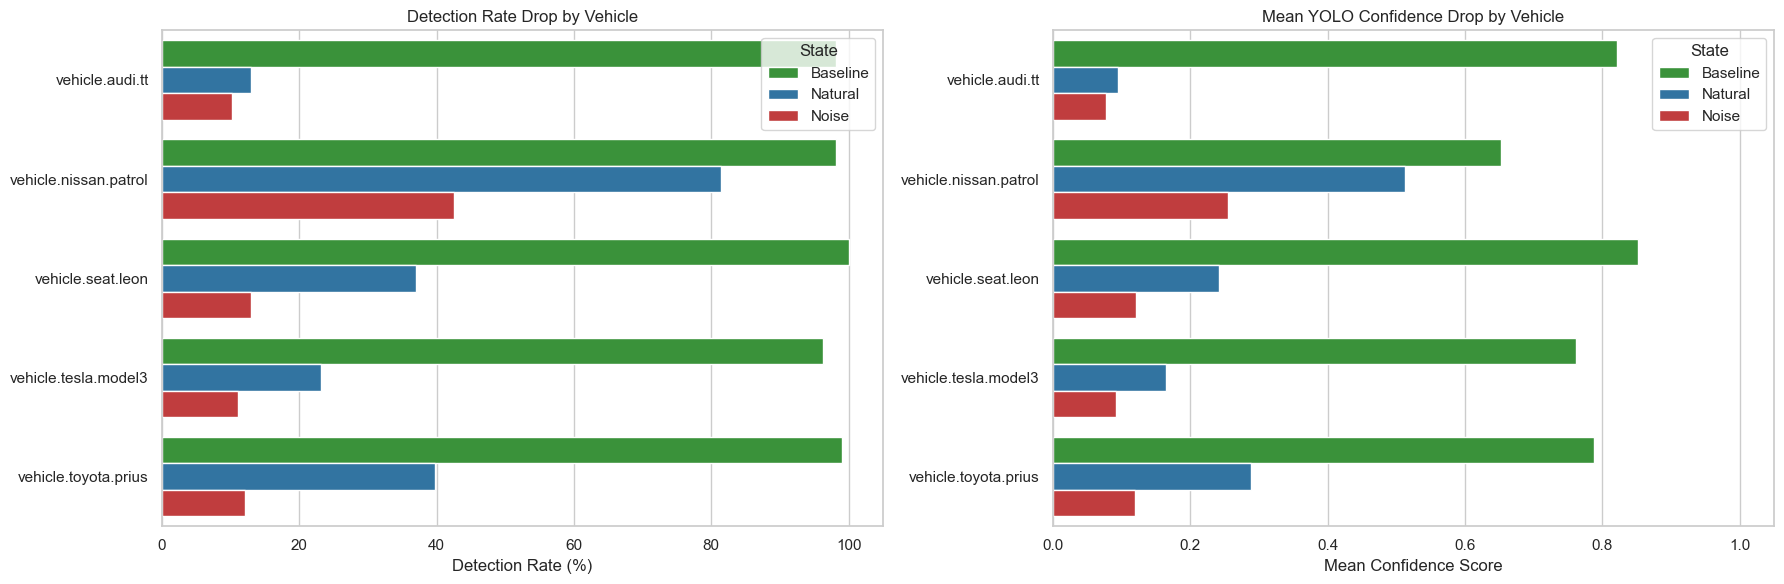

In [170]:
# 3. Vehicle Breakdown of Detection Rate & Confidence Drop

# 1. Baseline Stats
baseline_stats = df_final_natural.groupby('vehicle_id').agg(
    det_rate=('baseline_detected', lambda x: x.mean() * 100), mean_conf=('baseline_conf', 'mean')
).reset_index()
baseline_stats['State'] = 'Baseline'

# 2. Natural Stats
natural_stats = df_final_natural.groupby('vehicle_id').agg(
    det_rate=('patched_detected', lambda x: x.mean() * 100), mean_conf=('patched_conf', 'mean')
).reset_index()
natural_stats['State'] = 'Natural'

# 3. Noise Stats
noise_stats = df_final_noise.groupby('vehicle_id').agg(
    det_rate=('patched_detected', lambda x: x.mean() * 100), mean_conf=('patched_conf', 'mean')
).reset_index()
noise_stats['State'] = 'Noise'

veh_combined = pd.concat([baseline_stats, natural_stats, noise_stats], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=veh_combined, y='vehicle_id', x='det_rate', hue='State', ax=axes[0], palette=global_state_palette)
axes[0].set_title('Detection Rate Drop by Vehicle')
axes[0].set_xlabel('Detection Rate (%)')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 105)

sns.barplot(data=veh_combined, y='vehicle_id', x='mean_conf', hue='State', ax=axes[1], palette=global_state_palette)
axes[1].set_title('Mean YOLO Confidence Drop by Vehicle')
axes[1].set_xlabel('Mean Confidence Score')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

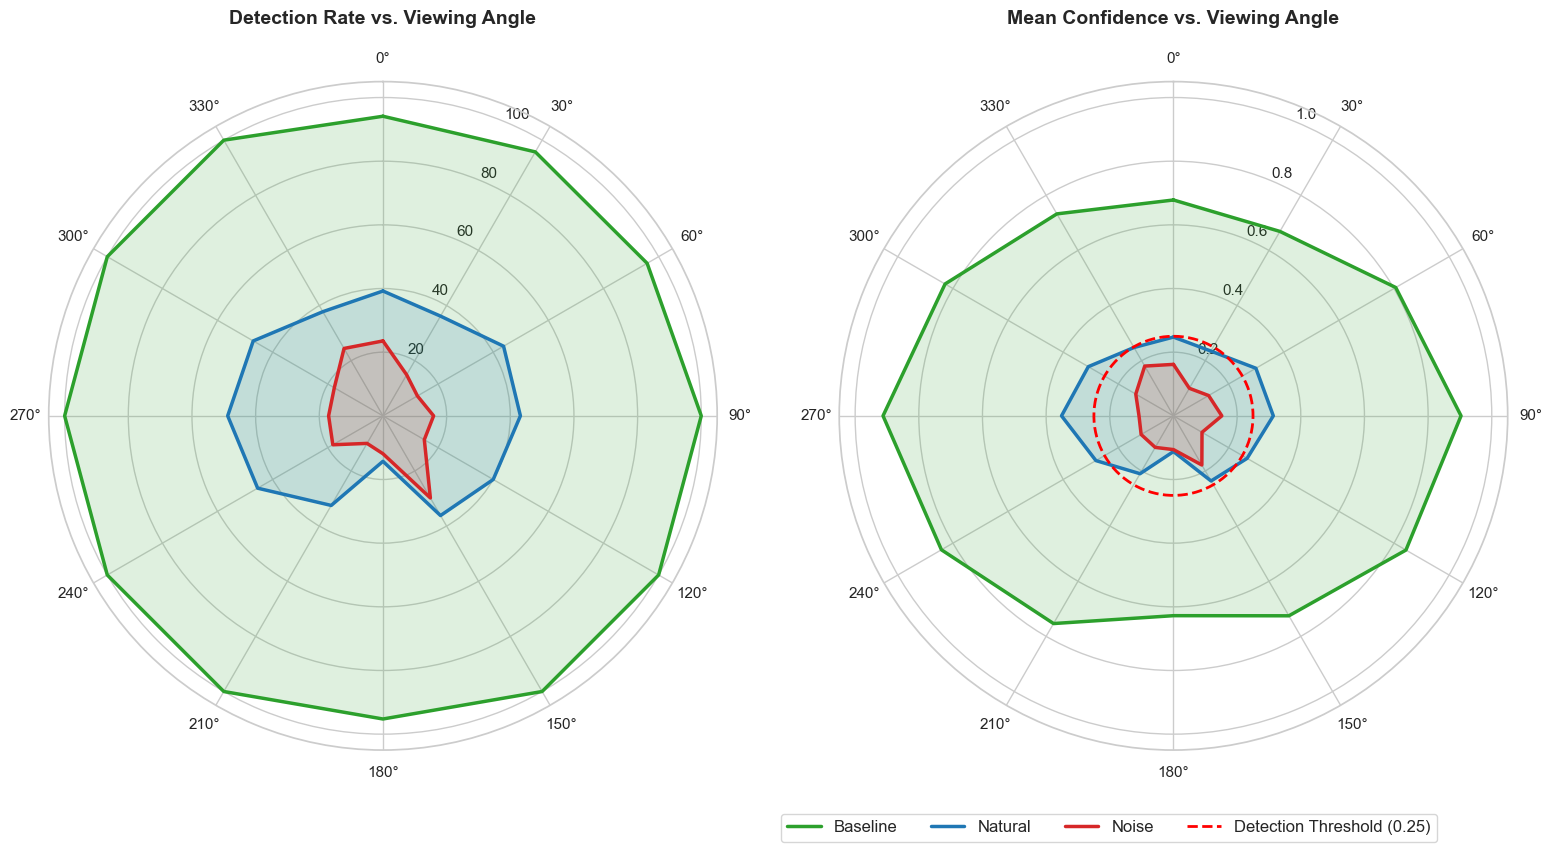

In [ ]:
# 4. Yaw Analysis: Detection Rate & Confidence by Viewing Angle


# function to extract and sort yaw metrics
def get_yaw_stats(df, prefix):
    return df.groupby('yaw').agg(
        det_rate=(f'{prefix}_detected', lambda x: x.mean() * 100),
        mean_conf=(f'{prefix}_conf', 'mean')
    ).reset_index().sort_values('yaw')

yaw_baseline = get_yaw_stats(df_final_natural, 'baseline')
yaw_natural  = get_yaw_stats(df_final_natural, 'patched')
yaw_noise    = get_yaw_stats(df_final_noise, 'patched')

# prep data for radar plots 
def prep_radar_data(df, metric):
    angles = np.append(np.deg2rad(df['yaw'].values), np.deg2rad(df['yaw'].values[0]))
    values = np.append(df[metric].values, df[metric].values[0])
    return angles, values


fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': 'polar'})

unique_yaws = sorted(df_final_natural['yaw'].unique())
unique_yaws_rad = np.deg2rad(unique_yaws)

plot_data = [
    ('Baseline', yaw_baseline, global_state_palette['Baseline']),
    ('Natural', yaw_natural, global_state_palette['Natural']),
    ('Noise', yaw_noise, global_state_palette['Noise'])
]

# plot both radars
for label, df, color in plot_data:
    # Plot Detection Rate
    ang_det, val_det = prep_radar_data(df, 'det_rate')
    axes[0].plot(ang_det, val_det, linewidth=2.5, color=color, label=label)
    axes[0].fill(ang_det, val_det, color=color, alpha=0.15)
    
    # Plot Mean Confidence
    ang_conf, val_conf = prep_radar_data(df, 'mean_conf')
    axes[1].plot(ang_conf, val_conf, linewidth=2.5, color=color, label=label)
    axes[1].fill(ang_conf, val_conf, color=color, alpha=0.15)

# add 0.25 Confidence Threshold Circle to the second plot
theta = np.linspace(0, 2 * np.pi, 100)
axes[1].plot(theta, np.full_like(theta, 0.25), color='red', linestyle='--', linewidth=2, label='Detection Threshold (0.25)')

for ax in axes:
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(unique_yaws_rad)
    ax.set_xticklabels([f"{int(deg)}°" for deg in unique_yaws])

axes[0].set_ylim(0, 105)
axes[0].set_title('Detection Rate vs. Viewing Angle', size=14, weight='bold', pad=20)

axes[1].set_ylim(0, 1.05)
axes[1].set_title('Mean Confidence vs. Viewing Angle', size=14, weight='bold', pad=20)

axes[1].legend(loc='lower left', bbox_to_anchor=(-0.1, -0.15), ncol=4, fontsize=12)

plt.tight_layout()
plt.show()

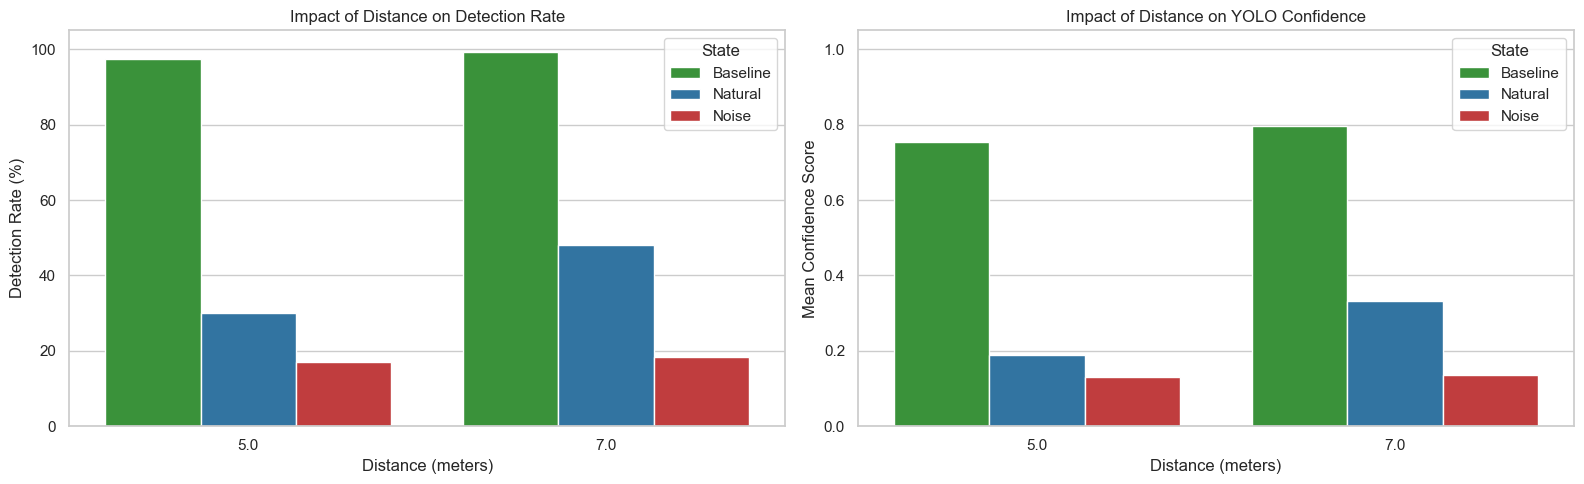

In [ ]:
# 5. Distance Analysis: Detection Rate & Confidence by Distance


dist_baseline = df_final_natural.groupby('distance').agg(
    det_rate=('baseline_detected', lambda x: x.mean() * 100), mean_conf=('baseline_conf', 'mean')).reset_index()
dist_baseline['State'] = 'Baseline'

dist_natural = df_final_natural.groupby('distance').agg(
    det_rate=('patched_detected', lambda x: x.mean() * 100), mean_conf=('patched_conf', 'mean')).reset_index()
dist_natural['State'] = 'Natural'

dist_noise = df_final_noise.groupby('distance').agg(
    det_rate=('patched_detected', lambda x: x.mean() * 100), mean_conf=('patched_conf', 'mean')).reset_index()
dist_noise['State'] = 'Noise'

dist_combined = pd.concat([dist_baseline, dist_natural, dist_noise], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=dist_combined, x='distance', y='det_rate', hue='State', ax=axes[0], palette=global_state_palette)
axes[0].set_title('Impact of Distance on Detection Rate')
axes[0].set_xlabel('Distance (meters)')
axes[0].set_ylabel('Detection Rate (%)')
axes[0].set_ylim(0, 105)

sns.barplot(data=dist_combined, x='distance', y='mean_conf', hue='State', ax=axes[1], palette=global_state_palette)
axes[1].set_title('Impact of Distance on YOLO Confidence')
axes[1].set_xlabel('Distance (meters)')
axes[1].set_ylabel('Mean Confidence Score')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

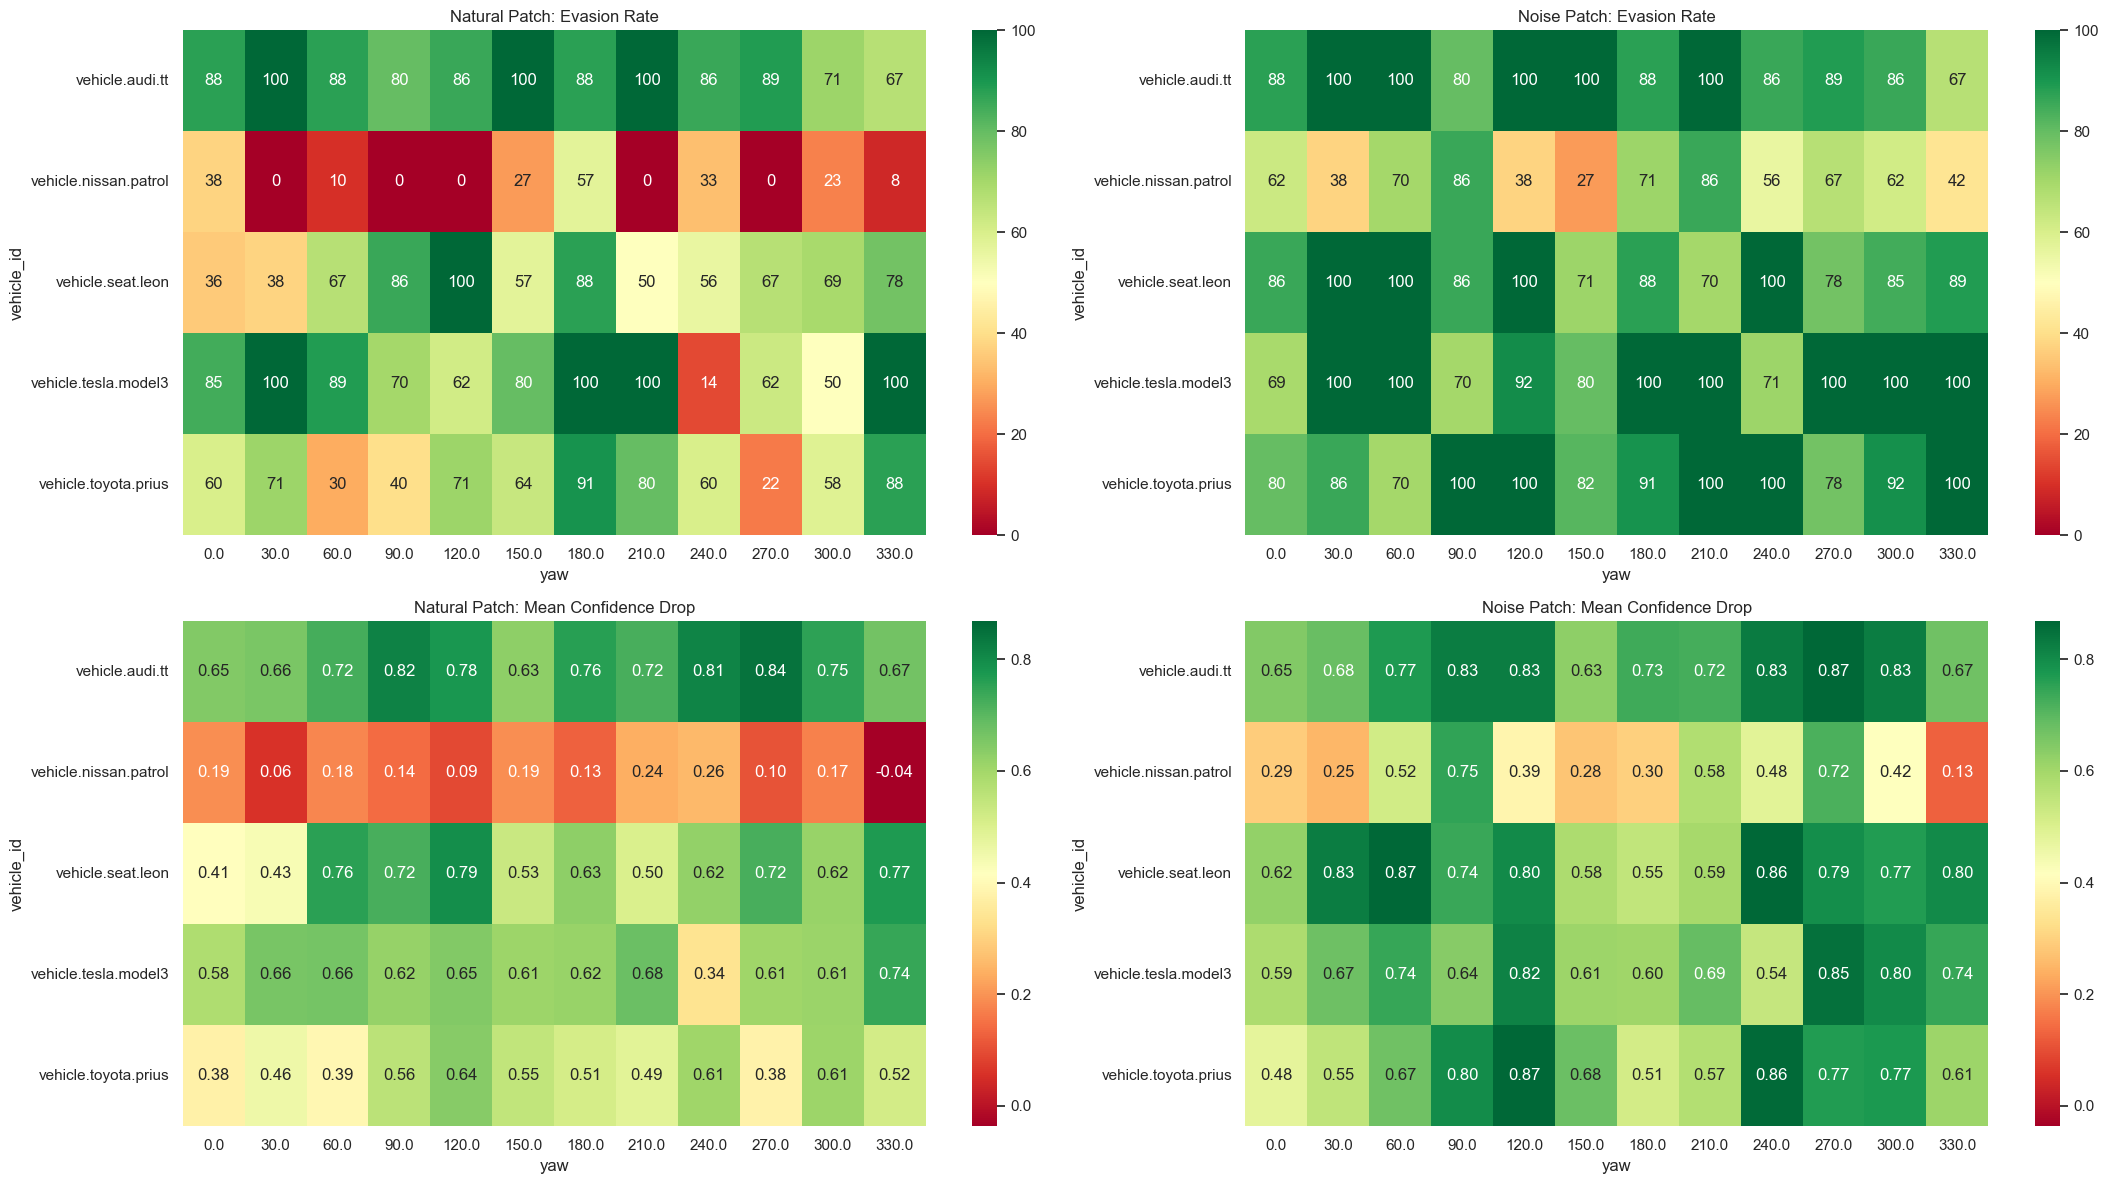

In [ ]:
# 6. Heatmap of Evasion Rate & Confidence Drop by Vehicle and Yaw

valid_natural = df_final_natural[df_final_natural['baseline_detected'] == 1]
valid_noise = df_final_noise[df_final_noise['baseline_detected'] == 1]

hm_evasion_nat = valid_natural.pivot_table(index='vehicle_id', columns='yaw', values='evasion_success', aggfunc=lambda x: x.mean() * 100)
hm_evasion_noise = valid_noise.pivot_table(index='vehicle_id', columns='yaw', values='evasion_success', aggfunc=lambda x: x.mean() * 100)
hm_conf_nat = valid_natural.pivot_table(index='vehicle_id', columns='yaw', values='conf_drop', aggfunc='mean')
hm_conf_noise = valid_noise.pivot_table(index='vehicle_id', columns='yaw', values='conf_drop', aggfunc='mean')

vmin_conf = min(hm_conf_nat.min().min(), hm_conf_noise.min().min())
vmax_conf = max(hm_conf_nat.max().max(), hm_conf_noise.max().max())

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

sns.heatmap(hm_evasion_nat, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100, ax=axes[0, 0])
axes[0, 0].set_title('Natural Patch: Evasion Rate')
sns.heatmap(hm_evasion_noise, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100, ax=axes[0, 1])
axes[0, 1].set_title('Noise Patch: Evasion Rate')

sns.heatmap(hm_conf_nat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=vmin_conf, vmax=vmax_conf, ax=axes[1, 0])
axes[1, 0].set_title('Natural Patch: Mean Confidence Drop')
sns.heatmap(hm_conf_noise, annot=True, fmt=".2f", cmap="RdYlGn", vmin=vmin_conf, vmax=vmax_conf, ax=axes[1, 1])
axes[1, 1].set_title('Noise Patch: Mean Confidence Drop')

plt.tight_layout()
plt.show()

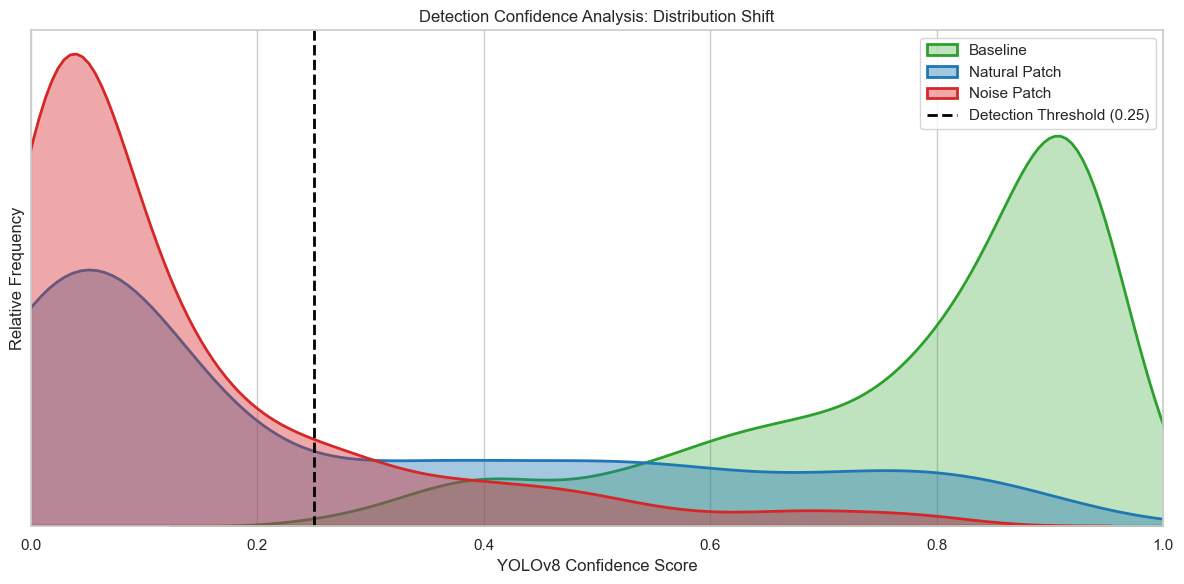

In [ ]:
# 7. Distribution Shift Analysis: Baseline vs. Patched Confidence Scores

plt.figure(figsize=(12, 6))
valid_natural = df_final_natural[df_final_natural['baseline_detected'] == 1]
valid_noise = df_final_noise[df_final_noise['baseline_detected'] == 1]

sns.kdeplot(data=valid_natural, x='baseline_conf', fill=True, 
            color=global_state_palette['Baseline'], alpha=0.3, linewidth=2, label='Baseline')

sns.kdeplot(data=valid_natural, x='patched_conf', fill=True, 
            color=global_state_palette['Natural'], alpha=0.4, linewidth=2, label='Natural Patch')

sns.kdeplot(data=valid_noise, x='patched_conf', fill=True, 
            color=global_state_palette['Noise'], alpha=0.4, linewidth=2, label='Noise Patch')

plt.axvline(x=0.25, color='black', linestyle='--', linewidth=2, label='Detection Threshold (0.25)')
plt.title('Detection Confidence Analysis: Distribution Shift')
plt.xlabel('YOLOv8 Confidence Score')
plt.ylabel('Relative Frequency')
plt.xlim(0, 1.0)
plt.yticks([]) 
plt.legend()
plt.tight_layout()
plt.show()

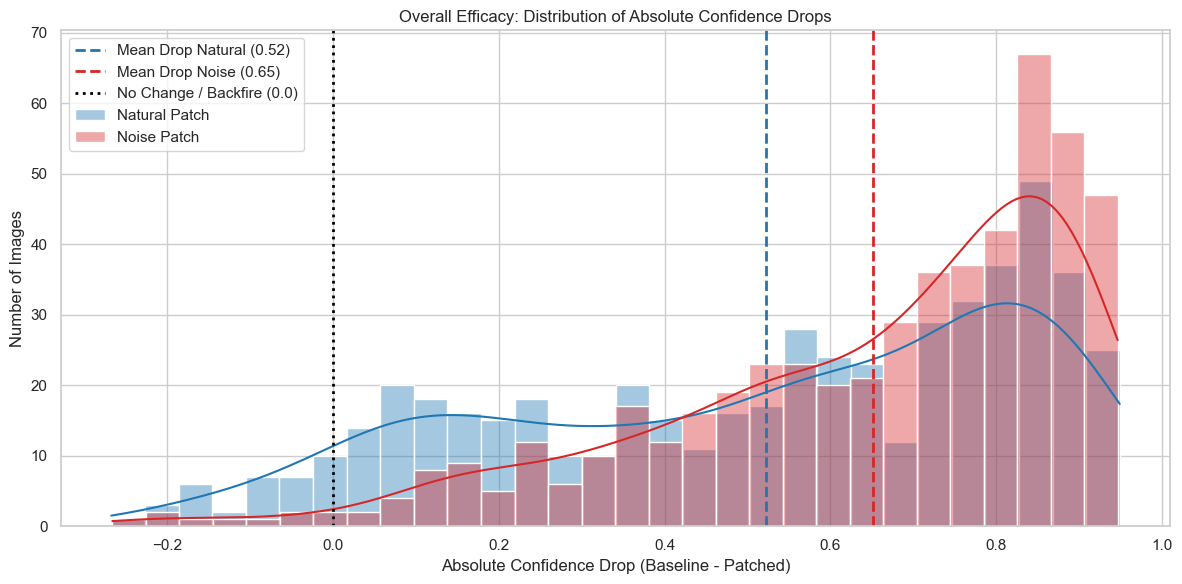

In [ ]:
# 8. Overall Efficacy: Distribution of Absolute Confidence Drops

plt.figure(figsize=(12, 6))

sns.histplot(data=valid_natural, x='conf_drop', color=global_state_palette['Natural'], 
             bins=30, kde=True, alpha=0.4, label='Natural Patch')

sns.histplot(data=valid_noise, x='conf_drop', color=global_state_palette['Noise'], 
             bins=30, kde=True, alpha=0.4, label='Noise Patch')

mean_drop_nat = valid_natural['conf_drop'].mean()
mean_drop_noise = valid_noise['conf_drop'].mean()

plt.axvline(x=mean_drop_nat, color=global_state_palette['Natural'], linestyle='--', linewidth=2, 
            label=f'Mean Drop Natural ({mean_drop_nat:.2f})')
plt.axvline(x=mean_drop_noise, color=global_state_palette['Noise'], linestyle='--', linewidth=2, 
            label=f'Mean Drop Noise ({mean_drop_noise:.2f})')

plt.axvline(x=0, color='black', linestyle=':', linewidth=2, label='No Change / Backfire (0.0)')

plt.title('Overall Efficacy: Distribution of Absolute Confidence Drops')
plt.xlabel('Absolute Confidence Drop (Baseline - Patched)')
plt.ylabel('Number of Images')
plt.legend()
plt.tight_layout()
plt.show()

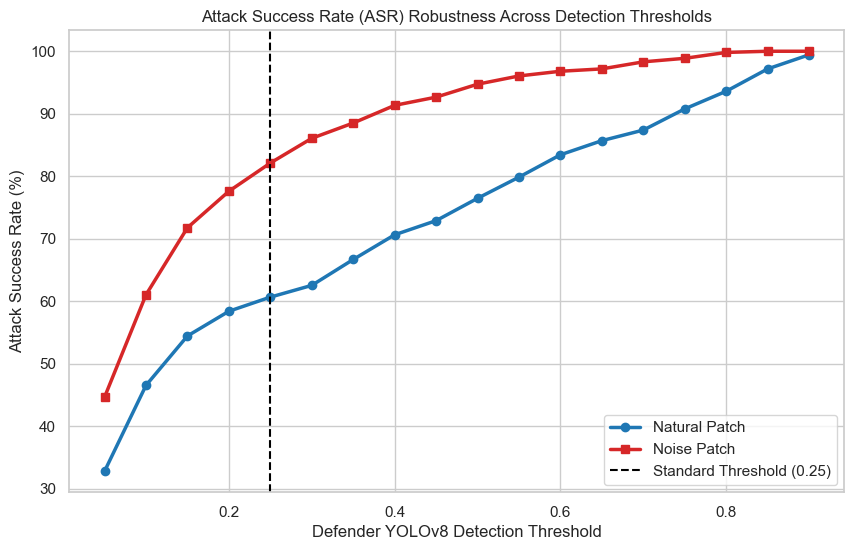

In [ ]:
# 9. ASR Robustness Across Detection Thresholds

thresholds = np.arange(0.05, 0.95, 0.05)
asr_nat, asr_noise = [], []

for t in thresholds:
    asr_nat.append((valid_natural[valid_natural['patched_conf'] < t].shape[0] / len(valid_natural)) * 100)
    asr_noise.append((valid_noise[valid_noise['patched_conf'] < t].shape[0] / len(valid_noise)) * 100)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, asr_nat, marker='o', color=global_state_palette['Natural'], linewidth=2.5, label='Natural Patch')
plt.plot(thresholds, asr_noise, marker='s', color=global_state_palette['Noise'], linewidth=2.5, label='Noise Patch')

plt.axvline(x=0.25, color='black', linestyle='--', label='Standard Threshold (0.25)')
plt.title('Attack Success Rate (ASR) Robustness Across Detection Thresholds')
plt.xlabel('Defender YOLOv8 Detection Threshold')
plt.ylabel('Attack Success Rate (%)')
plt.grid(True)
plt.legend()
plt.show()

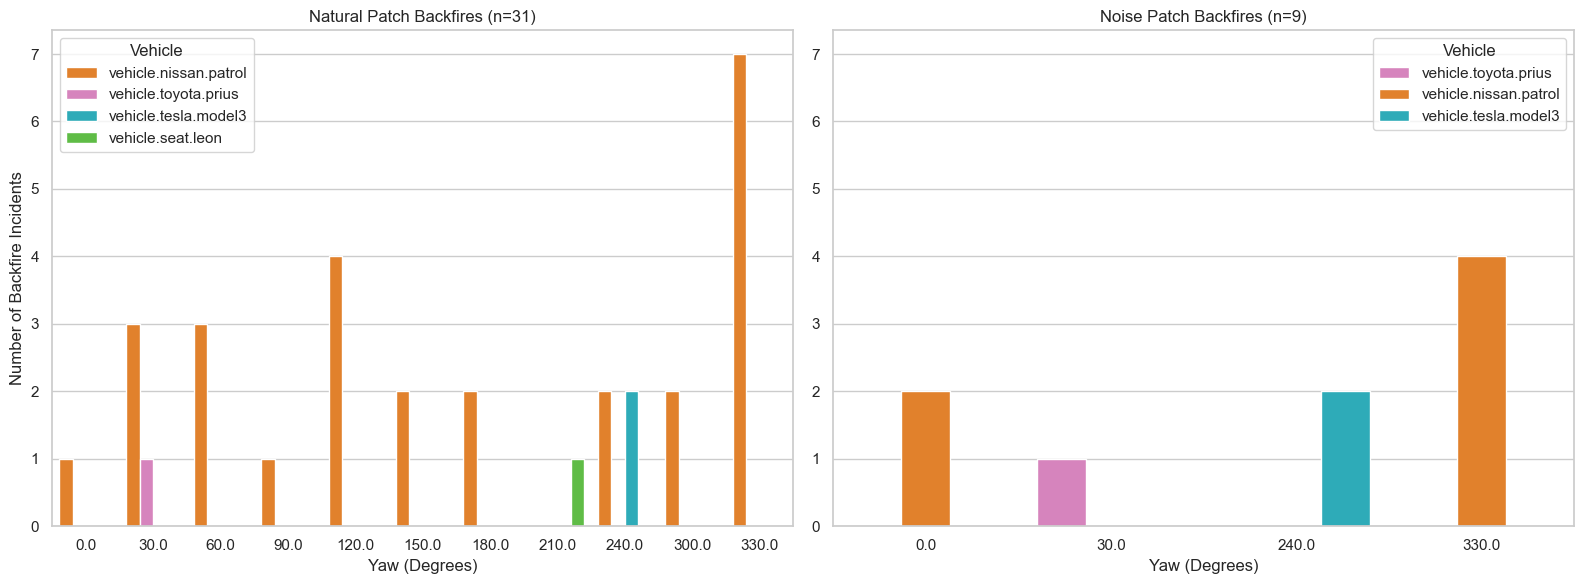

In [ ]:
# 10. Backfire Analysis: Incidents Where Confidence Increased (Negative Drop)

backfires_natural = df_final_natural[(df_final_natural['baseline_detected'] == 1) & (df_final_natural['conf_drop'] < 0)]
backfires_noise = df_final_noise[(df_final_noise['baseline_detected'] == 1) & (df_final_noise['conf_drop'] < 0)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if len(backfires_natural) > 0:
    sns.countplot(data=backfires_natural, x='yaw', hue='vehicle_id', palette=global_vehicle_palette, ax=axes[0]) # <--- LOCKED
    axes[0].set_title(f'Natural Patch Backfires (n={len(backfires_natural)})')
    axes[0].set_xlabel('Yaw (Degrees)')
    axes[0].set_ylabel('Number of Backfire Incidents')
    axes[0].legend(title='Vehicle')
else:
    axes[0].text(0.5, 0.5, "No Backfires Detected!", ha='center', va='center', fontsize=14, color=global_state_palette['Baseline'])
    axes[0].set_title('Natural Patch Backfires')
    axes[0].axis('off')

if len(backfires_noise) > 0:
    sns.countplot(data=backfires_noise, x='yaw', hue='vehicle_id', palette=global_vehicle_palette, ax=axes[1]) # <--- LOCKED
    axes[1].set_title(f'Noise Patch Backfires (n={len(backfires_noise)})')
    axes[1].set_xlabel('Yaw (Degrees)')
    axes[1].set_ylabel('') 
    axes[1].legend(title='Vehicle')
else:
    axes[1].text(0.5, 0.5, "No Backfires Detected!", ha='center', va='center', fontsize=14, color=global_state_palette['Baseline'])
    axes[1].set_title('Noise Patch Backfires')
    axes[1].axis('off')

if len(backfires_natural) > 0 and len(backfires_noise) > 0:
    max_y = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
    axes[0].set_ylim(0, max_y)
    axes[1].set_ylim(0, max_y)

plt.tight_layout()
plt.show()

Running Comprehensive Statistical Tests...


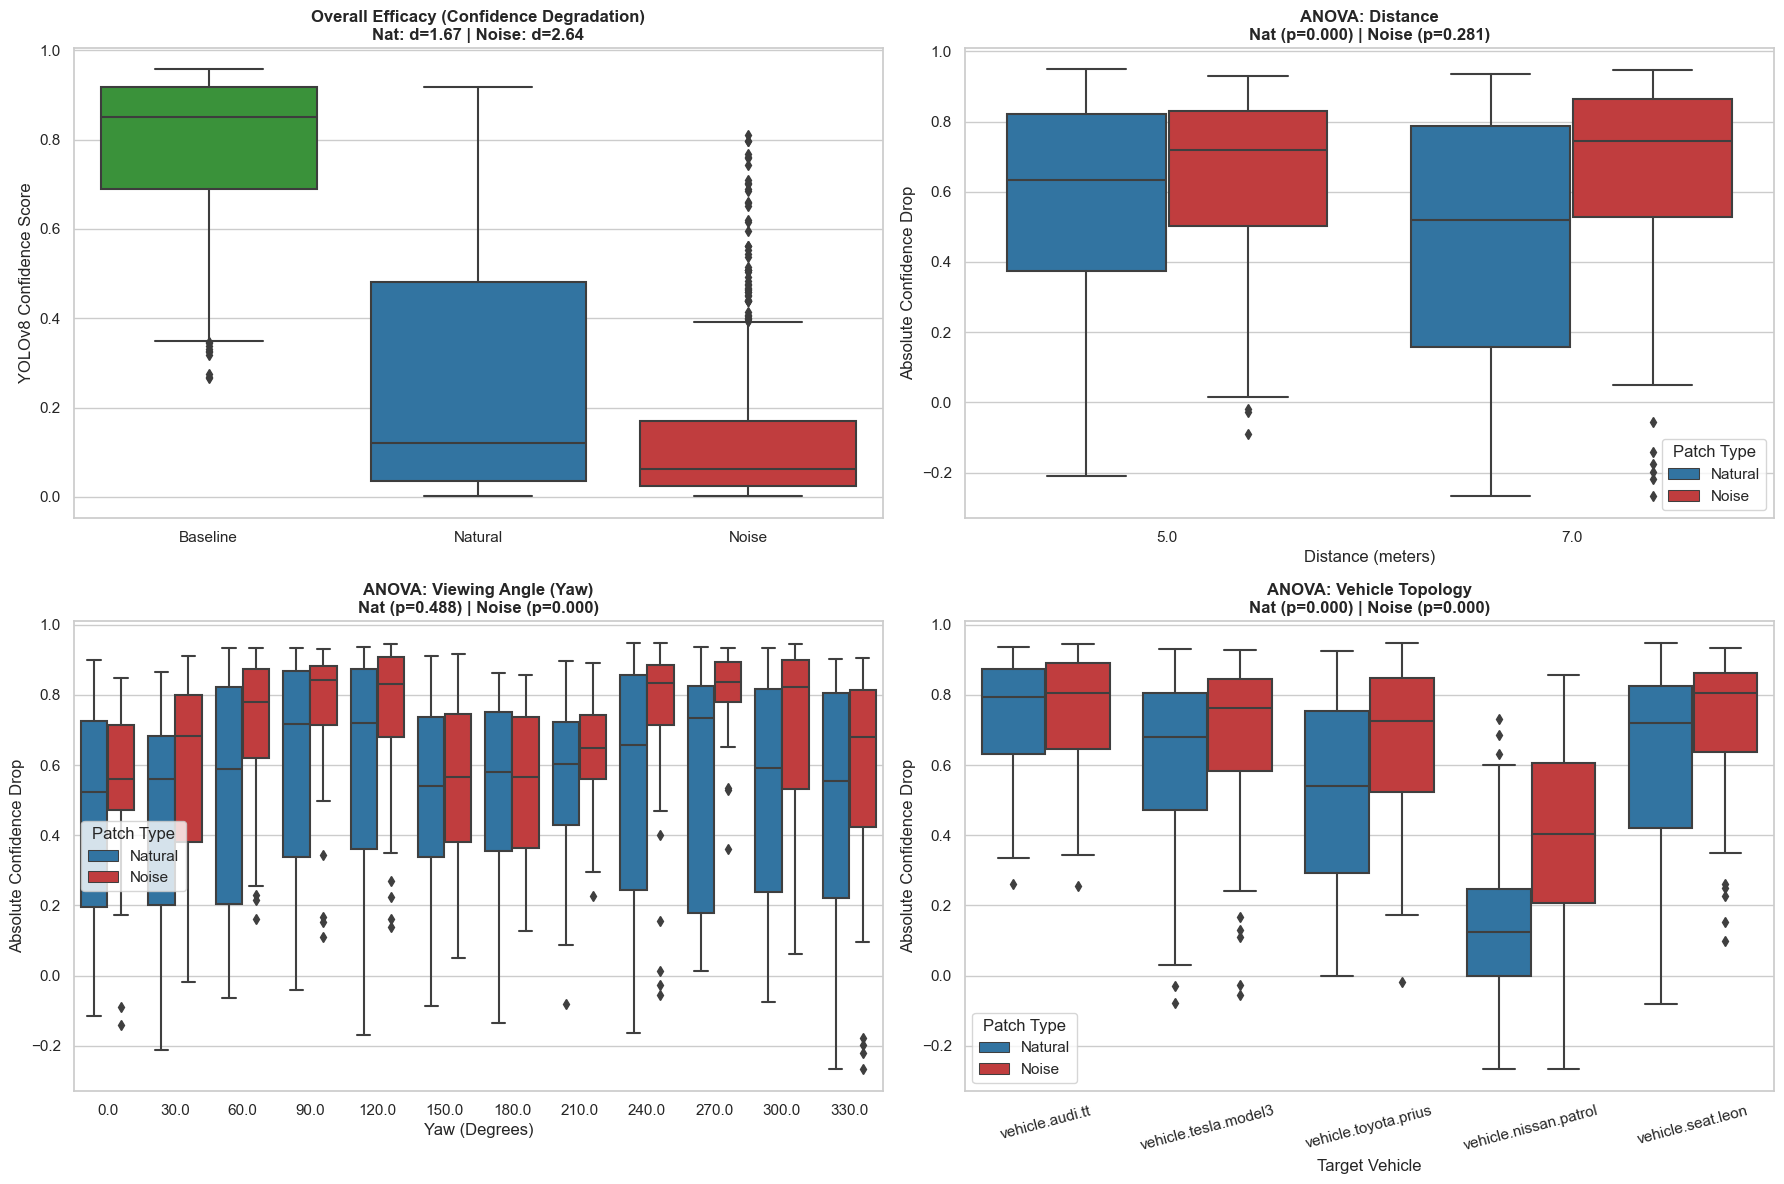


1. Overall Efficacy (Paired T-Tests):
   - Natural Patch: Highly significant drop (p = 2.04e-155), Effect Size (Cohen's d) = 1.67
   - Noise Patch:   Highly significant drop (p = 7.31e-241), Effect Size (Cohen's d) = 2.64
   - Direct Comparison: The difference in confidence drops between Natural and Noise was evaluated. (p = 1.4188e-33)

2. Impact of Distance (One-Way ANOVAs):
   - Natural Patch: F = 18.38, p = 0.0000 (Significant)
   - Noise Patch:   F = 1.17, p = 0.2806 (Not Significant)

3. Impact of Viewing Angle / Yaw (One-Way ANOVAs):
   - Natural Patch: F = 0.95, p = 0.4885 (Not Significant)
   - Noise Patch:   F = 7.28, p = 0.0000 (Significant)

4. Impact of Vehicle Topology (One-Way ANOVAs):
   - Natural Patch: F = 98.07, p = 0.0000 (Significant)
   - Noise Patch:   F = 48.10, p = 0.0000 (Significant)


In [ ]:

# 11. Formal Statistical Testing & Annotations

print("Running Comprehensive Statistical Tests...")

# only look at valid baseline detections
valid_natural = df_final_natural[df_final_natural['baseline_detected'] == 1].copy()
valid_noise = df_final_noise[df_final_noise['baseline_detected'] == 1].copy()

# labels for combined plotting
valid_natural['Patch'] = 'Natural'
valid_noise['Patch'] = 'Noise'
valid_combined = pd.concat([valid_natural, valid_noise], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()


def run_anova(df, group_col):
    groups = [group['conf_drop'].values for name, group in df.groupby(group_col)]
    return stats.f_oneway(*groups)

# T-Test: Baseline vs Natural
t_nat, p_nat = stats.ttest_rel(valid_natural['baseline_conf'], valid_natural['patched_conf'])
d_nat = (valid_natural['baseline_conf'] - valid_natural['patched_conf']).mean() / (valid_natural['baseline_conf'] - valid_natural['patched_conf']).std()

# T-Test: Baseline vs Noise
t_noise, p_noise = stats.ttest_rel(valid_noise['baseline_conf'], valid_noise['patched_conf'])
d_noise = (valid_noise['baseline_conf'] - valid_noise['patched_conf']).mean() / (valid_noise['baseline_conf'] - valid_noise['patched_conf']).std()

# T-Test: Natural vs Noise
t_direct, p_direct = stats.ttest_rel(valid_natural['conf_drop'], valid_noise['conf_drop'])

# Prep data for Boxplot
eff_base = valid_natural[['filename', 'baseline_conf']].rename(columns={'baseline_conf': 'Conf'}); eff_base['State'] = 'Baseline'
eff_nat = valid_natural[['filename', 'patched_conf']].rename(columns={'patched_conf': 'Conf'}); eff_nat['State'] = 'Natural'
eff_noise = valid_noise[['filename', 'patched_conf']].rename(columns={'patched_conf': 'Conf'}); eff_noise['State'] = 'Noise'
eff_df = pd.concat([eff_base, eff_nat, eff_noise])

sns.boxplot(data=eff_df, x='State', y='Conf', 
            palette={'Baseline': global_state_palette['Baseline'], 
                     'Natural': global_state_palette['Natural'],
                     'Noise': global_state_palette['Noise']}, 
            ax=axes[0])
axes[0].set_title(f"Overall Efficacy (Confidence Degradation)\nNat: d={d_nat:.2f} | Noise: d={d_noise:.2f}", fontweight='bold')
axes[0].set_ylabel('YOLOv8 Confidence Score')
axes[0].set_xlabel('')

# ANOVAs: distance
f_dist_nat, p_dist_nat = run_anova(valid_natural, 'distance')
f_dist_noise, p_dist_noise = run_anova(valid_noise, 'distance')

sns.boxplot(data=valid_combined, x='distance', y='conf_drop', hue='Patch', 
            palette={'Natural': global_state_palette['Natural'], 'Noise': global_state_palette['Noise']}, ax=axes[1])
axes[1].set_title(f"ANOVA: Distance\nNat (p={p_dist_nat:.3f}) | Noise (p={p_dist_noise:.3f})", fontweight='bold')
axes[1].set_ylabel('Absolute Confidence Drop')
axes[1].set_xlabel('Distance (meters)')
axes[1].legend(title='Patch Type')

# ANOVAs: yaw
f_yaw_nat, p_yaw_nat = run_anova(valid_natural, 'yaw')
f_yaw_noise, p_yaw_noise = run_anova(valid_noise, 'yaw')

sns.boxplot(data=valid_combined, x='yaw', y='conf_drop', hue='Patch', 
            palette={'Natural': global_state_palette['Natural'], 'Noise': global_state_palette['Noise']}, ax=axes[2])
axes[2].set_title(f"ANOVA: Viewing Angle (Yaw)\nNat (p={p_yaw_nat:.3f}) | Noise (p={p_yaw_noise:.3f})", fontweight='bold')
axes[2].set_ylabel('Absolute Confidence Drop')
axes[2].set_xlabel('Yaw (Degrees)')
axes[2].legend(title='Patch Type')

# ANOVAs: vehicle type
f_veh_nat, p_veh_nat = run_anova(valid_natural, 'vehicle_id')
f_veh_noise, p_veh_noise = run_anova(valid_noise, 'vehicle_id')

sns.boxplot(data=valid_combined, x='vehicle_id', y='conf_drop', hue='Patch', 
            palette={'Natural': global_state_palette['Natural'], 'Noise': global_state_palette['Noise']}, ax=axes[3])
axes[3].set_title(f"ANOVA: Vehicle Topology\nNat (p={p_veh_nat:.3f}) | Noise (p={p_veh_noise:.3f})", fontweight='bold')
axes[3].set_ylabel('Absolute Confidence Drop')
axes[3].set_xlabel('Target Vehicle')
axes[3].tick_params(axis='x', rotation=15)
axes[3].legend(title='Patch Type')

plt.tight_layout()
plt.show()

# Summaries for Write-Up
print("\n1. Overall Efficacy (Paired T-Tests):")
print(f"   - Natural Patch: Highly significant drop (p = {p_nat:.2e}), Effect Size (Cohen's d) = {d_nat:.2f}")
print(f"   - Noise Patch:   Highly significant drop (p = {p_noise:.2e}), Effect Size (Cohen's d) = {d_noise:.2f}")
print(f"   - Direct Comparison: The difference in confidence drops between Natural and Noise was evaluated. (p = {p_direct:.4e})")

print("\n2. Impact of Distance (One-Way ANOVAs):")
print(f"   - Natural Patch: F = {f_dist_nat:.2f}, p = {p_dist_nat:.4f} " + ("(Significant)" if p_dist_nat < 0.05 else "(Not Significant)"))
print(f"   - Noise Patch:   F = {f_dist_noise:.2f}, p = {p_dist_noise:.4f} " + ("(Significant)" if p_dist_noise < 0.05 else "(Not Significant)"))

print("\n3. Impact of Viewing Angle / Yaw (One-Way ANOVAs):")
print(f"   - Natural Patch: F = {f_yaw_nat:.2f}, p = {p_yaw_nat:.4f} " + ("(Significant)" if p_yaw_nat < 0.05 else "(Not Significant)"))
print(f"   - Noise Patch:   F = {f_yaw_noise:.2f}, p = {p_yaw_noise:.4f} " + ("(Significant)" if p_yaw_noise < 0.05 else "(Not Significant)"))

print("\n4. Impact of Vehicle Topology (One-Way ANOVAs):")
print(f"   - Natural Patch: F = {f_veh_nat:.2f}, p = {p_veh_nat:.4f} " + ("(Significant)" if p_veh_nat < 0.05 else "(Not Significant)"))
print(f"   - Noise Patch:   F = {f_veh_noise:.2f}, p = {p_veh_noise:.4f} " + ("(Significant)" if p_veh_noise < 0.05 else "(Not Significant)"))